# Data Preparation

In [1]:
import pandas as pd

from src.categories import tp_level_categories
from src.compare import compare_transformations, compare_skewness, compare_distributions
from src.derive import derive_epi
from src.descriptions import prep_measurements, prep_descriptions
from src.eda import understand_features, assess_features, find_central_tendency, measure_variability, \
    visualize_distribution, correlate_features, scatter_plot_features, line_plot_features
from src.enums import prep_keys, prefixes, files, rv_keys, keys, aq_keys
from src.transform import Transformation, transform

aq_prep = pd.read_csv(files['data/04-01-open-meteo-cleaned-aggregated.csv'])
rv_prep = pd.read_csv(files['data/04-01-respiratory-virus-dashboard-cleaned-transformed.csv'])

## Stabilize air quality data

Further analysis showed that previously stabilized data become skewed again after aggregation. Also, previously extremely skewed columns can now be stabilized with transformations. We are applying stabilization to these columns again.

Features that cannot be stabilized would have been discretized.

### Compare skewness across different transformations

In [2]:
compare_transformations(aq_prep)

,Original,Square root,Log transformation,Cube root,Yeo-Johnson Transform
SEASON,N/A,N/A,N/A,N/A,N/A
WEEKENDING,N/A,N/A,N/A,N/A,N/A
MMWR_WEEK,-0.19,-0.69,-1.25,-0.91,-0.32
MMWR_YEAR,-0.06,-0.06,-0.06,-0.06,-0.03
us_aqi (USAQI),1.54,1.03,0.63,0.88,0.03
us_aqi_pm2_5 (USAQI),0.59,0.16,-0.27,0.01,0.01
us_aqi_pm10 (USAQI),0.71,0.36,0.05,0.24,0.0
us_aqi_nitrogen_dioxide (USAQI),-0.21,-0.47,-0.75,-0.57,-0.19
us_aqi_carbon_monoxide (USAQI),1.0,0.58,0.35,0.45,0.07
us_aqi_ozone (USAQI),2.04,1.39,0.84,1.19,-0.03


### Transform skewed features

In [3]:
transformations = {
    prep_keys['us_aqi_pm2_5 (USAQI)']: Transformation.SQRT,
    prep_keys['us_aqi_pm10 (USAQI)']: Transformation.SQRT,
    prep_keys['us_aqi_sulphur_dioxide (USAQI)']: Transformation.SQRT,
    prep_keys['aerosol_optical_depth ()']: Transformation.SQRT,
    prep_keys['nitrogen_dioxide (μg/m³)']: Transformation.SQRT,
    prep_keys['pm10 (μg/m³)']: Transformation.SQRT,

    prep_keys['us_aqi_carbon_monoxide (USAQI)']: Transformation.LOG1P,
    prep_keys['pm2_5 (μg/m³)']: Transformation.LOG1P,
    prep_keys['carbon_monoxide (μg/m³)']: Transformation.LOG1P,

    prep_keys['us_aqi (USAQI)']: Transformation.YEO_JOHNSON,
    prep_keys['us_aqi_ozone (USAQI)']: Transformation.YEO_JOHNSON,
    prep_keys['dust (μg/m³)']: Transformation.YEO_JOHNSON,
    prep_keys['sulphur_dioxide (μg/m³)']: Transformation.YEO_JOHNSON,
}
aq_transformed = transform(
    aq_prep,
    transformations,
    prefixes['04_01_data_preparation_']
)

### Skewness comparison

In [4]:
compare_skewness(aq_prep, aq_transformed, transformations)

,Changes,Skewness (Original),Skewness (Target)
us_aqi_pm2_5 (USAQI),sqrt,0.59,0.16
us_aqi_pm10 (USAQI),sqrt,0.71,0.36
us_aqi_sulphur_dioxide (USAQI),sqrt,1.37,0.47
aerosol_optical_depth (),sqrt,0.65,0.31
nitrogen_dioxide (μg/m³),sqrt,0.8,0.45
pm10 (μg/m³),sqrt,0.55,0.2
us_aqi_carbon_monoxide (USAQI),log1p,1.0,0.35
pm2_5 (μg/m³),log1p,1.22,0.4
carbon_monoxide (μg/m³),log1p,1.26,0.52
us_aqi (USAQI),yeo-johnson,1.54,0.03


### Distribution comparison

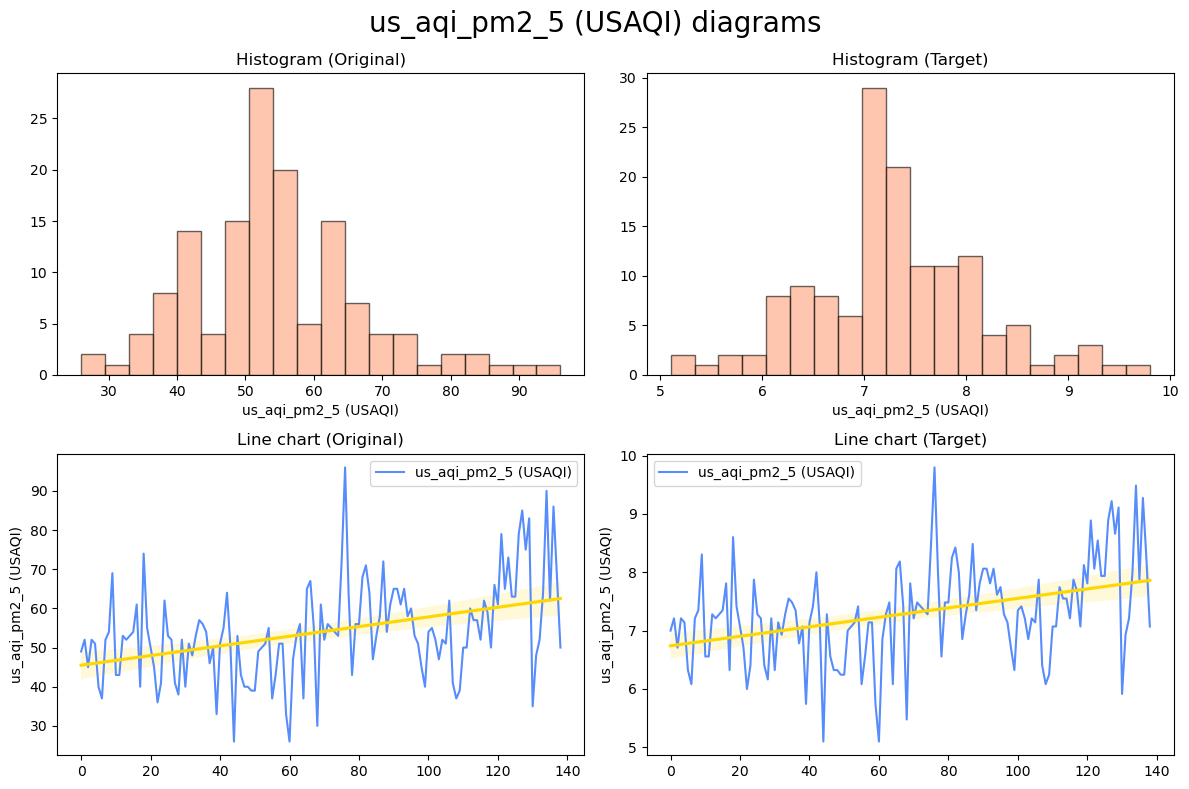

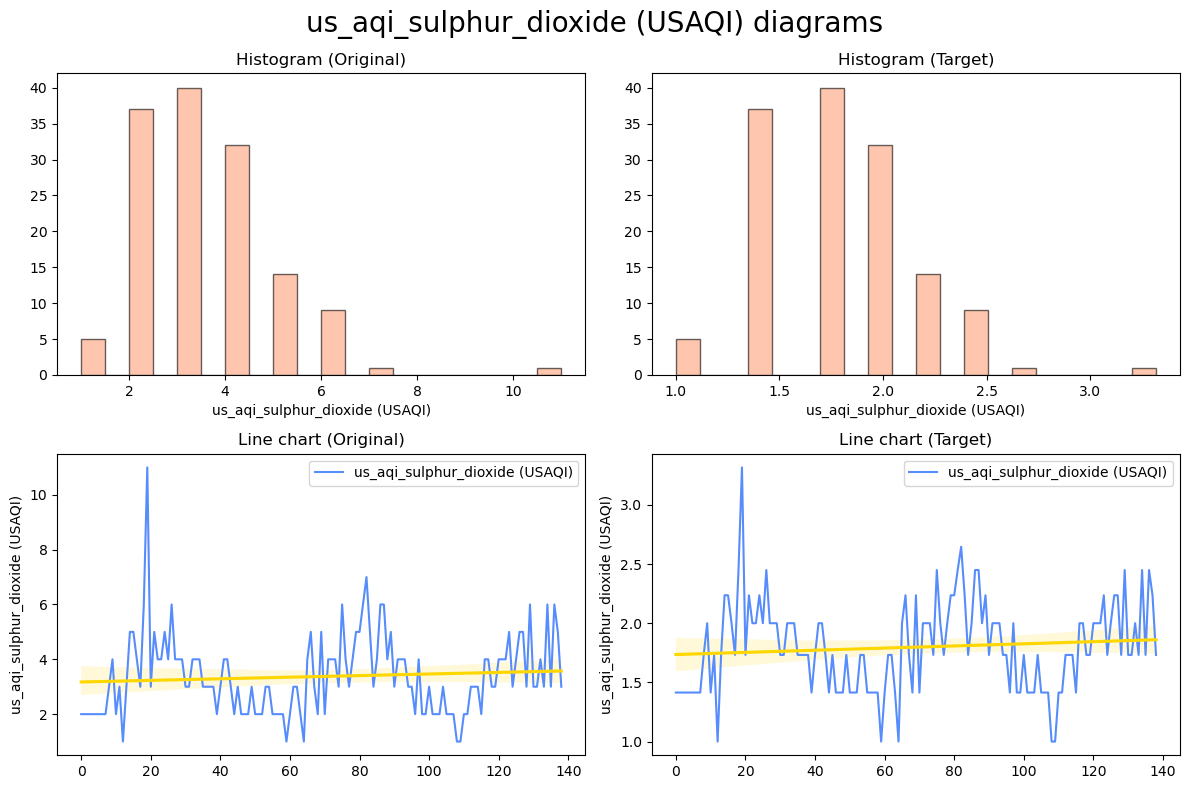

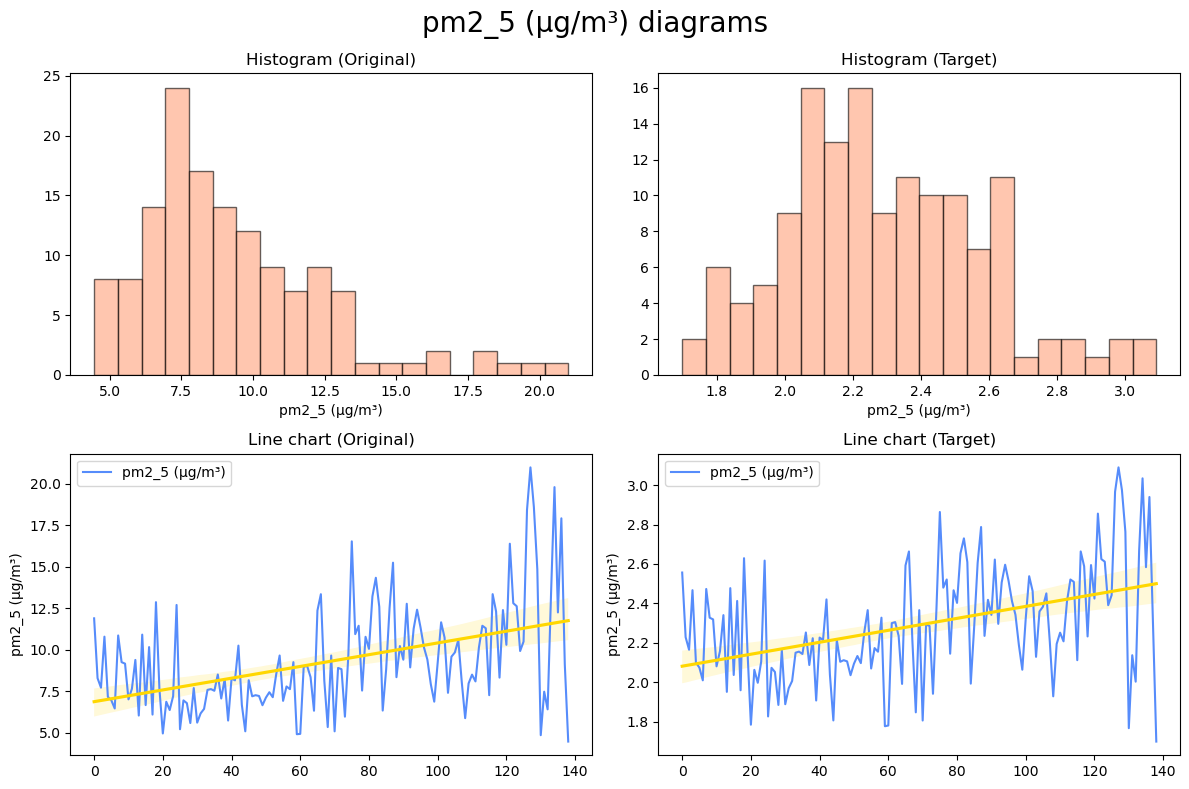

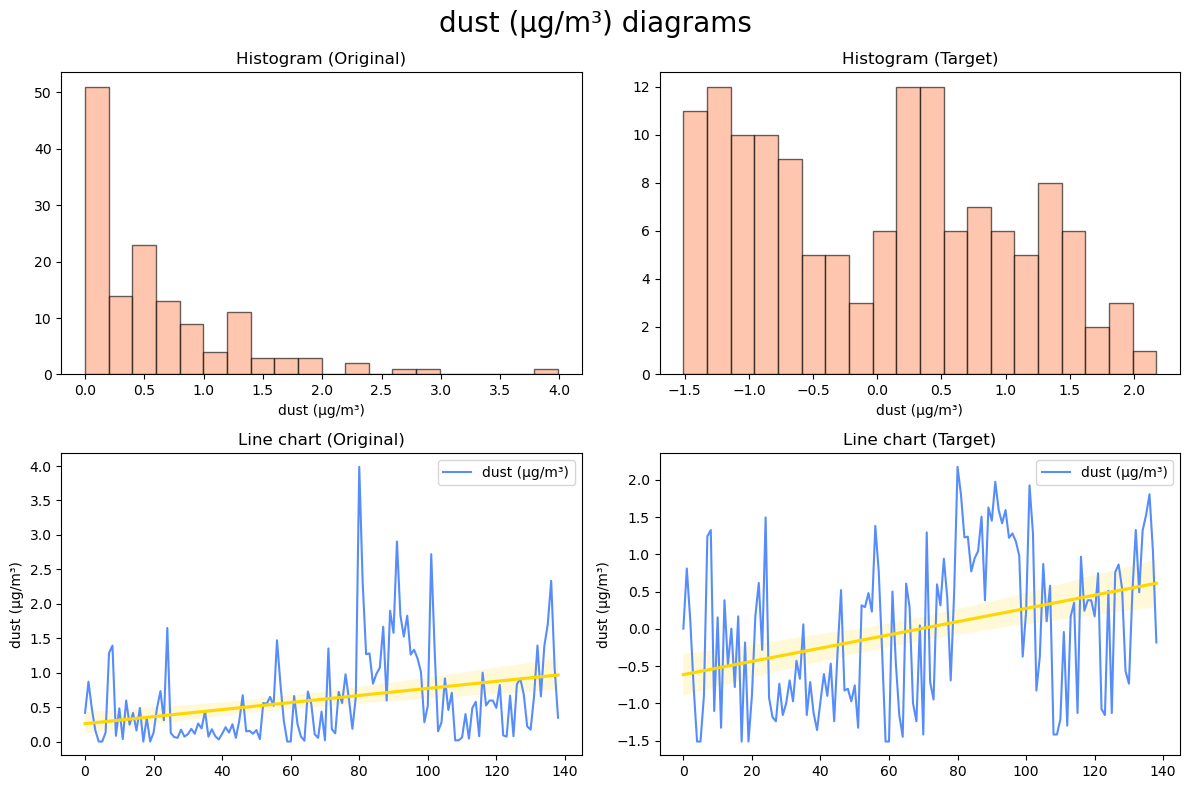

In [5]:
compare_distributions(
    aq_prep,
    aq_transformed,
    [
        prep_keys['us_aqi_pm2_5 (USAQI)'], # square root transformation.
        prep_keys['us_aqi_sulphur_dioxide (USAQI)'], # square root transformation.
        prep_keys['pm2_5 (μg/m³)'], # log transformation.
        prep_keys['dust (μg/m³)'] # Yeo-Johnson transformation.
    ]
)

## Discretize categorical features

Discretize categorical columns so that they can be correlated with numeric columns.

### Determine value counts for each column

In [6]:
value_counts = pd.concat([
    rv_prep[prep_keys['COV_TP_LEVEL']].value_counts(),
    rv_prep[prep_keys['FLU_TP_LEVEL']].value_counts(),
    rv_prep[prep_keys['RSV_TP_LEVEL']].value_counts(),
], axis=1)
value_counts.columns = [prep_keys['COV_TP_LEVEL'], prep_keys['FLU_TP_LEVEL'], prep_keys['RSV_TP_LEVEL']]

value_counts

,COV_TP_LEVEL,FLU_TP_LEVEL,RSV_TP_LEVEL
Very Low,60.0,19,60
Low,51.0,74,31
Moderate,28.0,11,25
High,1.0,25,11
Very High,NaN,11,13


### Convert discrete strings to ordinal values

In [7]:
rv_discretized = rv_prep.copy();

rv_discretized[prep_keys['COV_TP_LEVEL']] = pd.Categorical(
    rv_discretized[prep_keys['COV_TP_LEVEL']],
    categories=tp_level_categories,
    ordered=True
)
rv_discretized[prep_keys['FLU_TP_LEVEL']] = pd.Categorical(
    rv_discretized[prep_keys['FLU_TP_LEVEL']],
    categories=tp_level_categories,
    ordered=True
)
rv_discretized[prep_keys['RSV_TP_LEVEL']] = pd.Categorical(
    rv_discretized[prep_keys['RSV_TP_LEVEL']],
    categories=tp_level_categories,
    ordered=True
)

rv_preview = rv_discretized.copy()
rv_preview[prep_keys['COV_TP_LEVEL'] + '_order'] = rv_preview[prep_keys['COV_TP_LEVEL']].cat.codes
rv_preview[prep_keys['FLU_TP_LEVEL'] + '_order'] = rv_preview[prep_keys['FLU_TP_LEVEL']].cat.codes
rv_preview[prep_keys['RSV_TP_LEVEL'] + '_order'] = rv_preview[prep_keys['RSV_TP_LEVEL']].cat.codes

rv_preview.head(3)

,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,COV_POSITIVES,COV_TOTAL_TESTS,COV_TP,COV_TP_LEVEL,FLU_POSITIVES,FLU_TOTAL_TESTS,...,TOTAL_DEATHS,COV_DEATHS,FLU_DEATHS,RSV_DEATHS,COV_DEATHS_PER,FLU_DEATHS_PER,RSV_DEATHS_PER,COV_TP_LEVEL_order,FLU_TP_LEVEL_order,RSV_TP_LEVEL_order
0,2023/2024,07/08/2023,27,2023,42.414620,40924,2.096653,Low,4.248495,39.306488,...,-0.263756,4.690416,-0.266598,-0.919797,1.435244,-0.451111,-0.887000,1,1,0
1,2023/2024,07/15/2023,28,2023,45.276926,41354,2.226477,Low,4.532599,40.865633,...,-0.842204,4.000000,-1.299923,-0.919797,1.256768,-1.138038,-0.887000,1,1,0
2,2023/2024,07/22/2023,29,2023,47.180504,41390,2.319075,Low,3.850148,39.127995,...,-0.545089,4.123106,-1.299923,0.463280,1.277293,-1.138038,0.323507,1,1,0


## Stitch data
Combine datasets through their SEASON, WEEKENDING, MMWR_WEEK, MMWR_YEAR features.

In [8]:
df_prep = pd.merge(
    aq_transformed,
    rv_discretized,
    on=[
        prep_keys['SEASON'],
        prep_keys['WEEKENDING'],
        prep_keys['MMWR_WEEK'],
        prep_keys['MMWR_YEAR']
    ],
    how='inner'
)

print(f'Row length: {len(df_prep)}')
df_prep.head(3)

Row length: 138


,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,us_aqi (USAQI),us_aqi_pm2_5 (USAQI),us_aqi_pm10 (USAQI),us_aqi_nitrogen_dioxide (USAQI),us_aqi_carbon_monoxide (USAQI),us_aqi_ozone (USAQI),...,RSV_TOTAL_TESTS,RSV_TP,RSV_TP_LEVEL,TOTAL_DEATHS,COV_DEATHS,FLU_DEATHS,RSV_DEATHS,COV_DEATHS_PER,FLU_DEATHS_PER,RSV_DEATHS_PER
0,2023/2024,07/08/2023,27,2023,0.014406,7.211103,4.242641,14,1.386294,0.746694,...,39.370039,0.416160,Very Low,-0.263756,4.690416,-0.266598,-0.919797,1.435244,-0.451111,-0.887000
1,2023/2024,07/15/2023,28,2023,-0.232912,6.708204,3.872983,15,1.098612,0.576871,...,40.509258,0.513017,Very Low,-0.842204,4.000000,-1.299923,-0.919797,1.256768,-1.138038,-0.887000
2,2023/2024,07/22/2023,29,2023,-0.321393,7.211103,4.358899,15,1.098612,0.179761,...,38.961519,0.653505,Very Low,-0.545089,4.123106,-1.299923,0.463280,1.277293,-1.138038,0.323507


## Understand features

Identify what kind of information is in each column, such as measurement and description.

In [9]:
understand_features(df_prep, prep_measurements, prep_descriptions)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   SEASON                           138 non-null    object  
 1   WEEKENDING                       138 non-null    object  
 2   MMWR_WEEK                        138 non-null    int64   
 3   MMWR_YEAR                        138 non-null    int64   
 4   us_aqi (USAQI)                   138 non-null    float64 
 5   us_aqi_pm2_5 (USAQI)             138 non-null    float64 
 6   us_aqi_pm10 (USAQI)              138 non-null    float64 
 7   us_aqi_nitrogen_dioxide (USAQI)  138 non-null    int64   
 8   us_aqi_carbon_monoxide (USAQI)   138 non-null    float64 
 9   us_aqi_ozone (USAQI)             138 non-null    float64 
 10  us_aqi_sulphur_dioxide (USAQI)   138 non-null    float64 
 11  uv_index ()                      138 non-null    float64 
 12  uv_index

,Measurement Type,Description
us_aqi (USAQI),ordinal,Air Quality Index is the overall standardized ...
us_aqi_pm2_5 (USAQI),ordinal,AQI for PM2.5 particles.
us_aqi_pm10 (USAQI),ordinal,AQI for PM10 particles.
us_aqi_nitrogen_dioxide (USAQI),ordinal,AQI for Nitrogen Dioxide.
us_aqi_carbon_monoxide (USAQI),ordinal,AQI for Carbon Monoxide.
us_aqi_ozone (USAQI),ordinal,AQI for Ozone.
us_aqi_sulphur_dioxide (USAQI),ordinal,AQI for Sulphur Dioxide.
uv_index_clear_sky (),ratio,Measurement of the intensity of ultraviolet ra...
uv_index (),ratio,Measurement of the intensity of ultraviolet ra...
dust (μg/m³),ratio,Dust particles in the air that can cause cough...


## Assess features

Document anomalies such as missing and NaN values.

In [10]:
assess_features(df_prep, prep_measurements)

,Null Count,Null Percentage,Measurement Type,Duplicate Count,Duplicate Percentage
SEASON,0,0.0,nominal,135,97.83
WEEKENDING,0,0.0,interval,0,0.00
MMWR_WEEK,0,0.0,interval,85,61.59
MMWR_YEAR,0,0.0,interval,134,97.10
us_aqi (USAQI),0,0.0,ordinal,90,65.22
us_aqi_pm2_5 (USAQI),0,0.0,ordinal,91,65.94
us_aqi_pm10 (USAQI),0,0.0,ordinal,117,84.78
us_aqi_nitrogen_dioxide (USAQI),0,0.0,ordinal,106,76.81
us_aqi_carbon_monoxide (USAQI),0,0.0,ordinal,128,92.75
us_aqi_ozone (USAQI),0,0.0,ordinal,90,65.22


## Find central tendency of features

Determine if the data is symmetrical. If the data is skewed, a more robust scaling method should be used, like log scaling.

In [11]:
find_central_tendency(df_prep, prep_measurements)

,Measurement Type,Mean,Median,Skewness,Skew Direction
us_aqi (USAQI),ordinal,-0.0,-0.11,0.043275,Symmetrical
us_aqi_pm2_5 (USAQI),ordinal,7.3,7.28,0.151886,Symmetrical
us_aqi_pm10 (USAQI),ordinal,4.16,4.12,0.352063,Symmetrical
us_aqi_nitrogen_dioxide (USAQI),ordinal,22.67,24.0,-0.222222,Symmetrical
us_aqi_carbon_monoxide (USAQI),ordinal,1.58,1.61,0.338257,Symmetrical
us_aqi_ozone (USAQI),ordinal,-0.01,-0.05,-0.015614,Symmetrical
us_aqi_sulphur_dioxide (USAQI),ordinal,1.8,1.73,0.454094,Symmetrical
uv_index_clear_sky (),ratio,6.36,6.3,0.031876,Symmetrical
uv_index (),ratio,6.2,6.0,0.017978,Symmetrical
dust (μg/m³),ratio,-0.0,0.12,0.172475,Symmetrical


## Measure variability of features

Determine variability using both mean and median-based methods.

In [12]:
measure_variability(df_prep)

,Feature,q1,q3,iqr,std_dev,cv,lower_limit,upper_limit
0,MMWR_WEEK,14.25,41.00,26.75,15.52,0.55,-25.88,81.12
1,MMWR_YEAR,2024.00,2025.00,1.00,0.83,0.00,2022.50,2026.50
2,us_aqi (USAQI),-0.58,0.62,1.21,1.00,-202.49,-2.39,2.44
3,us_aqi_pm2_5 (USAQI),6.86,7.81,0.95,0.83,0.11,5.42,9.24
4,us_aqi_pm10 (USAQI),3.74,4.47,0.73,0.53,0.13,2.65,5.57
5,us_aqi_nitrogen_dioxide (USAQI),15.00,30.00,15.00,8.48,0.37,-7.50,52.50
6,us_aqi_carbon_monoxide (USAQI),1.39,1.79,0.41,0.37,0.23,0.78,2.40
7,us_aqi_ozone (USAQI),-0.52,0.48,1.00,1.00,-113.69,-2.02,1.99
8,us_aqi_sulphur_dioxide (USAQI),1.41,2.00,0.59,0.38,0.21,0.54,2.88
9,uv_index (),3.19,9.05,5.86,2.95,0.48,-5.61,17.84


## Visualize distribution of features

Visualize the distribution of each feature to understand the data better and identify any anomalies or patterns.

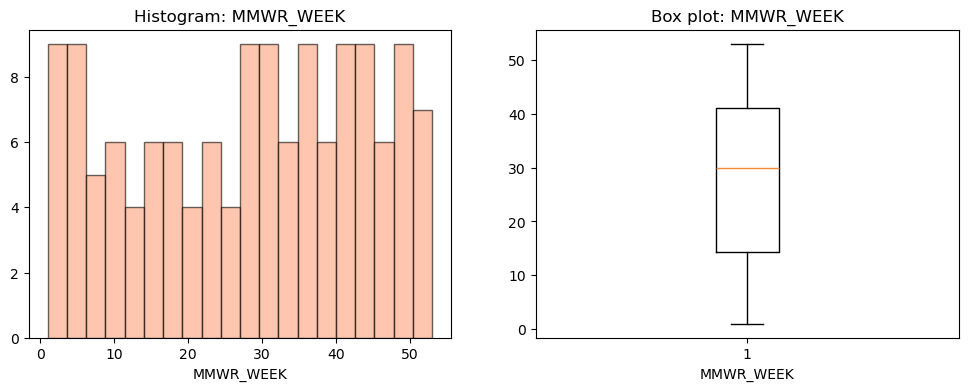

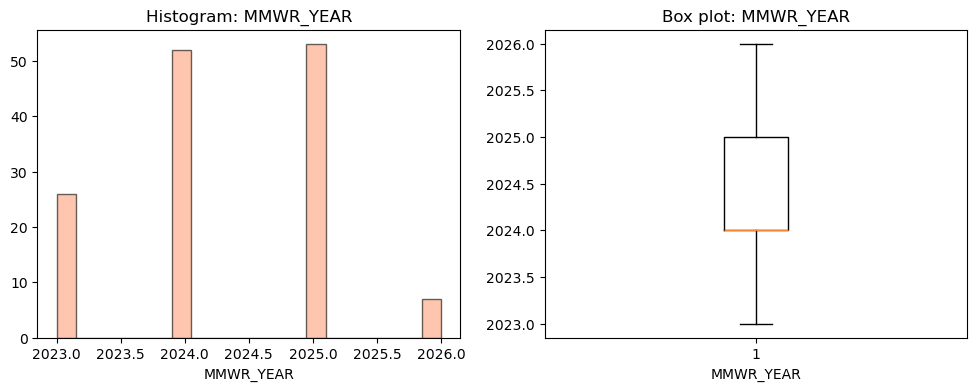

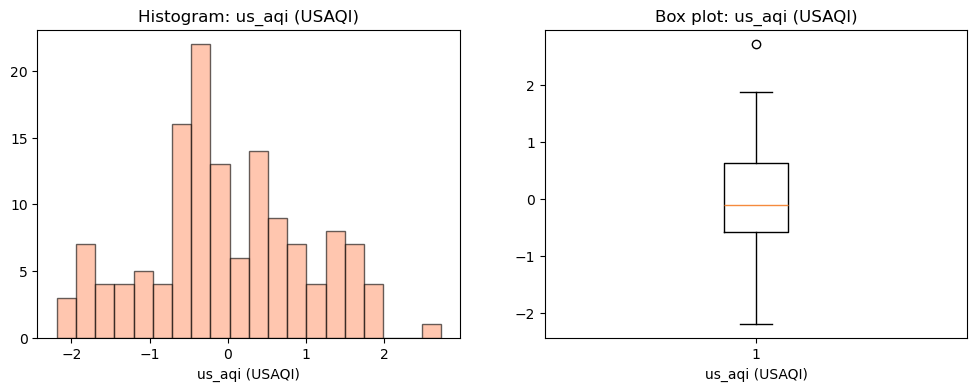

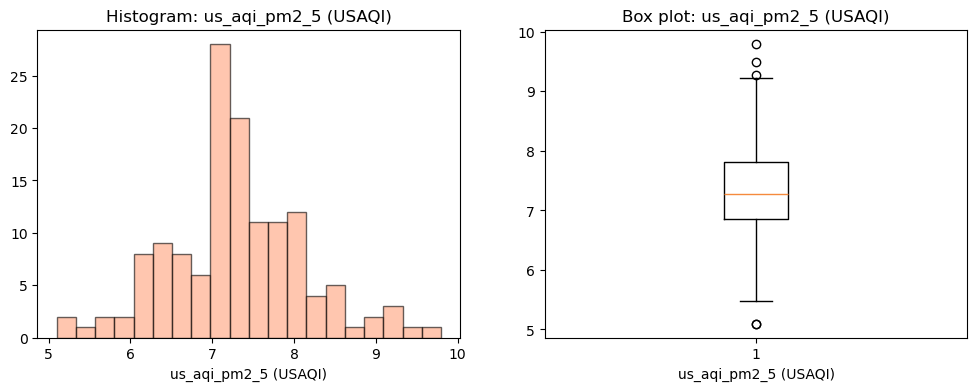

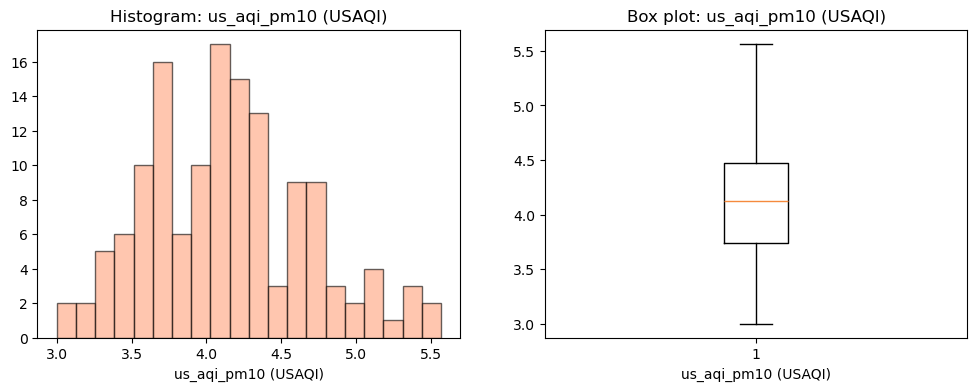

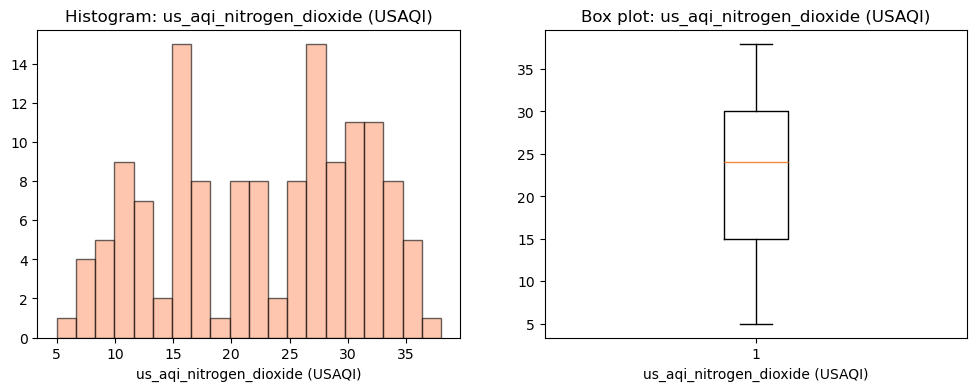

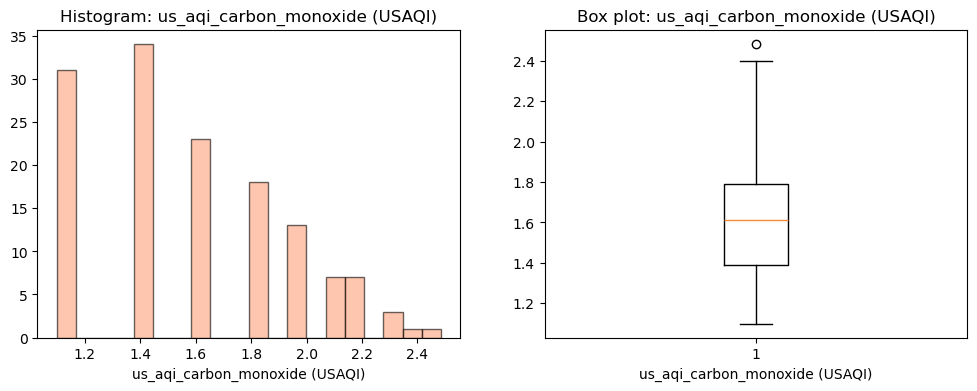

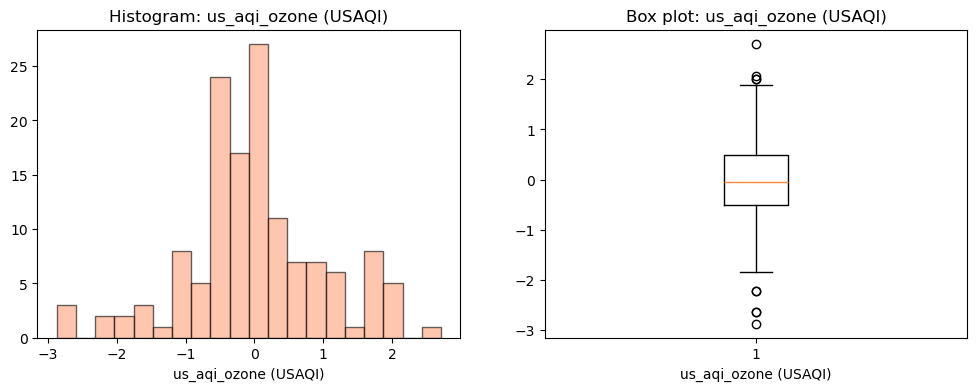

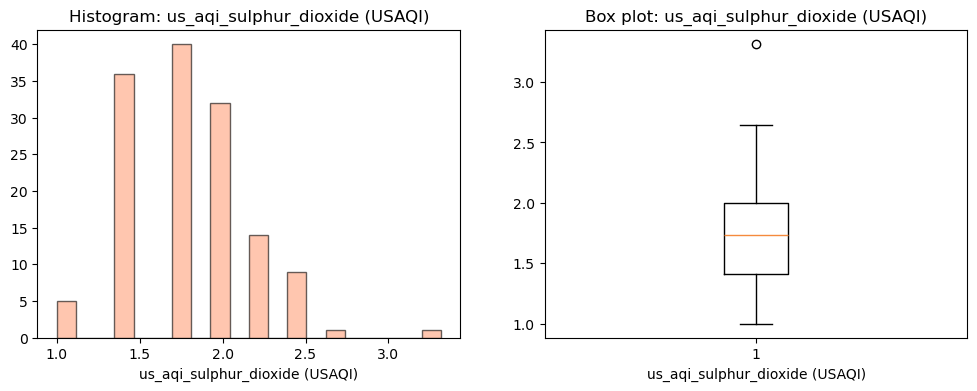

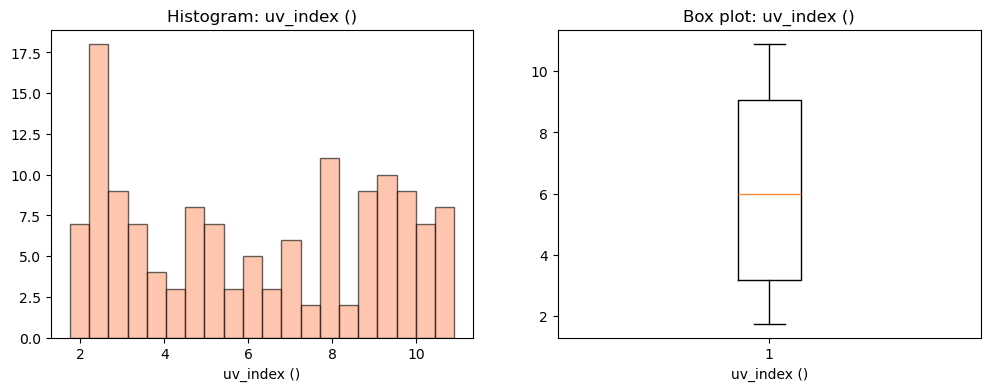

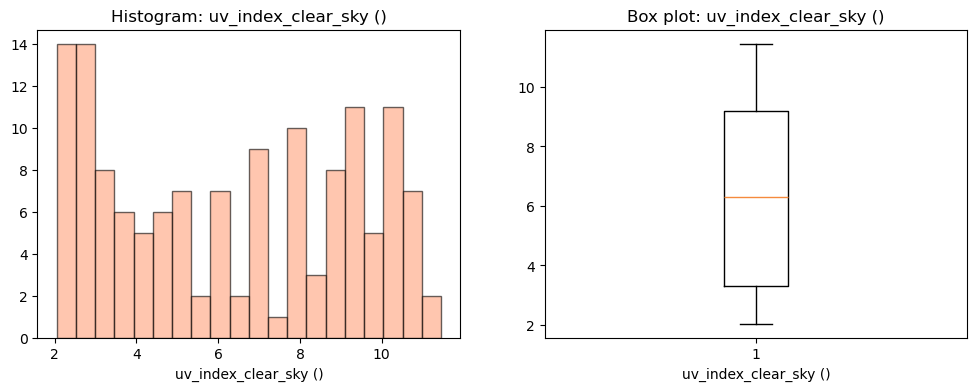

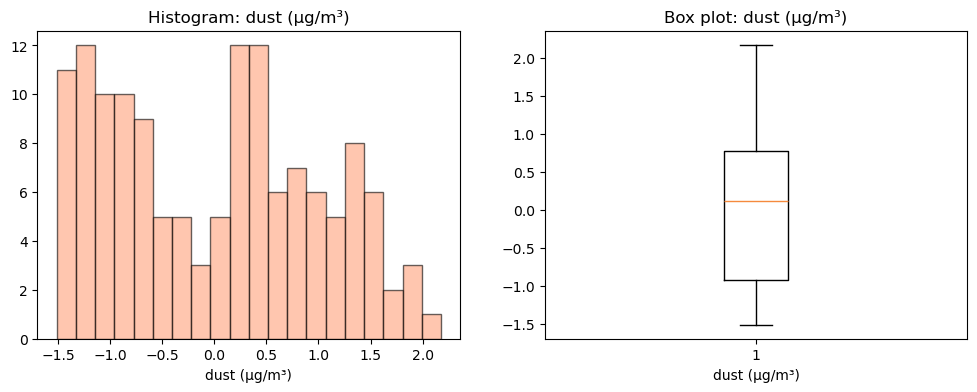

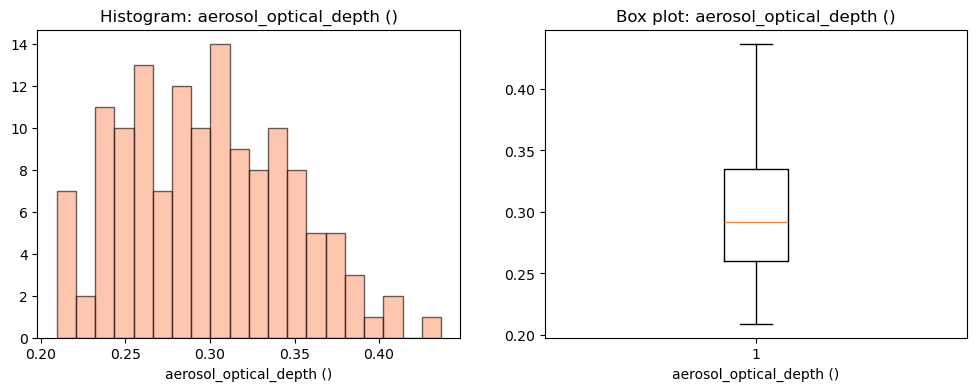

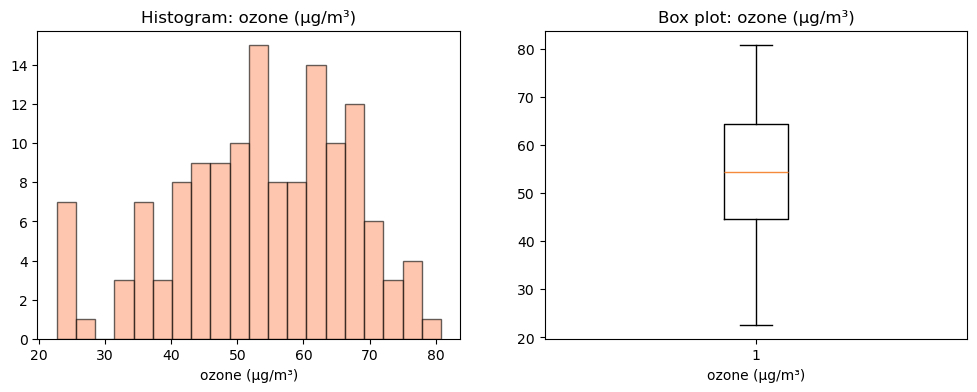

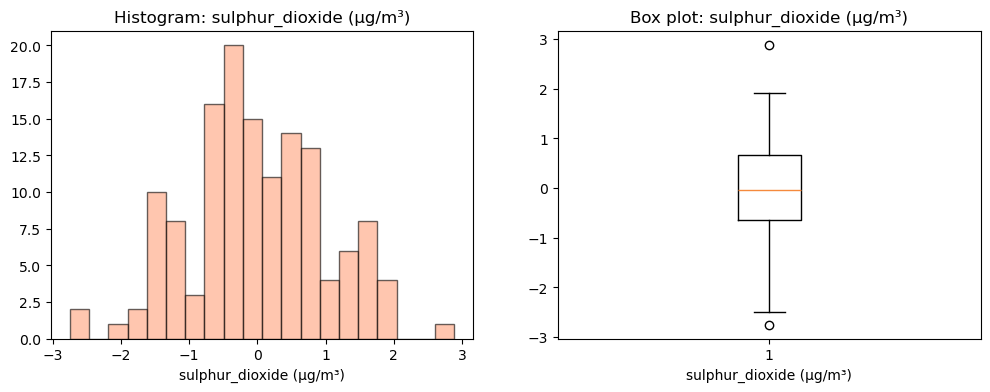

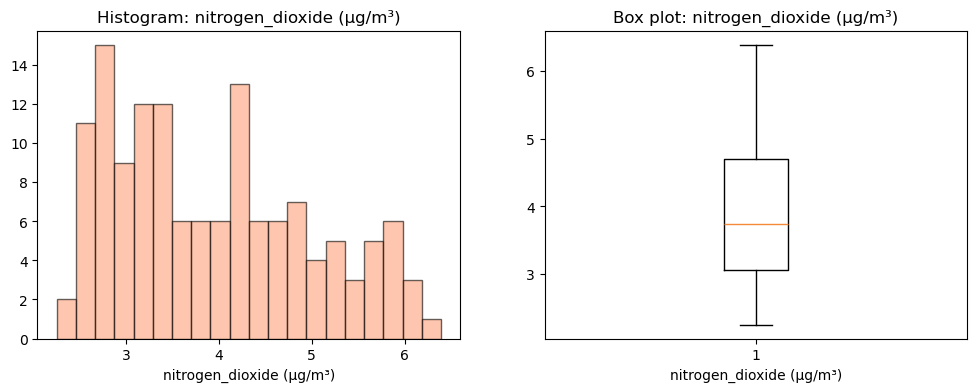

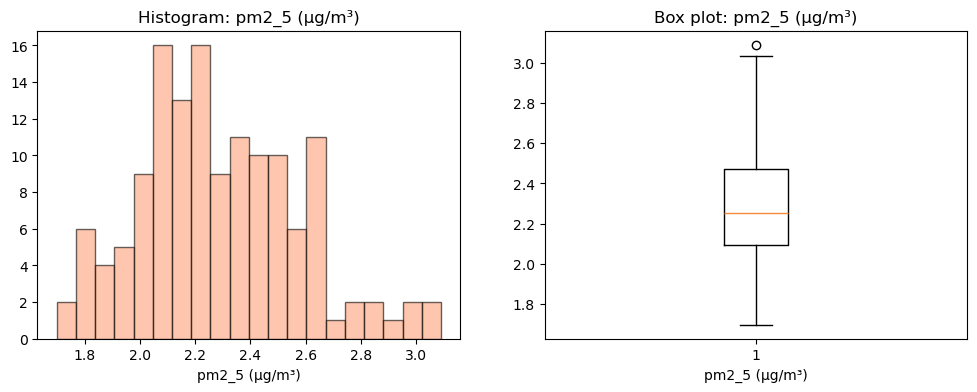

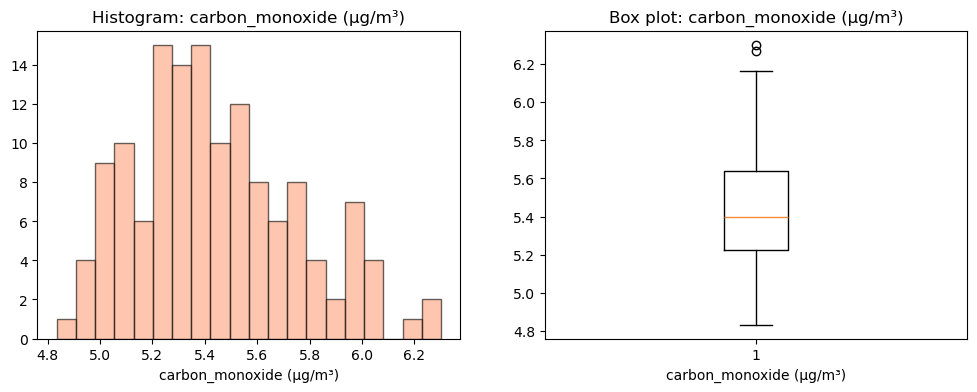

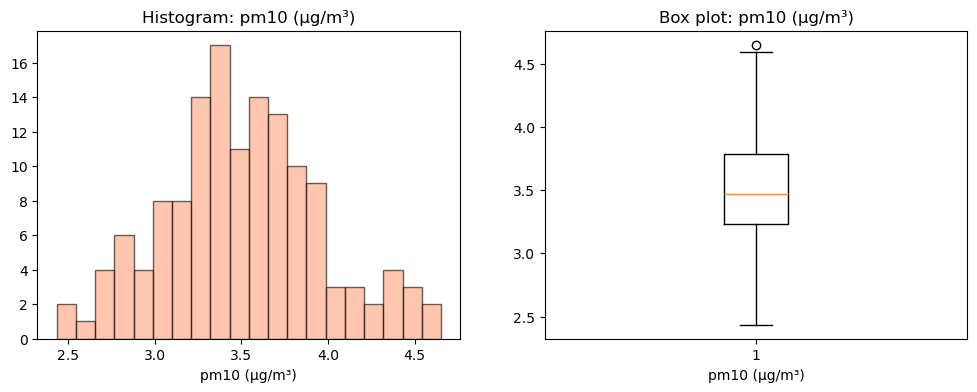

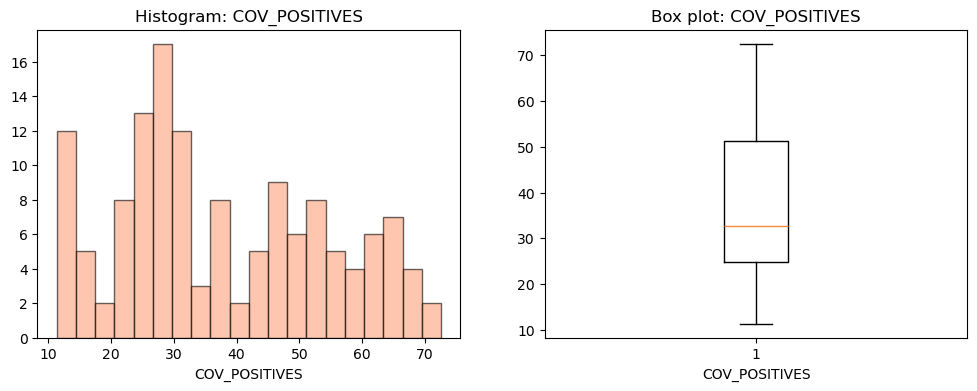

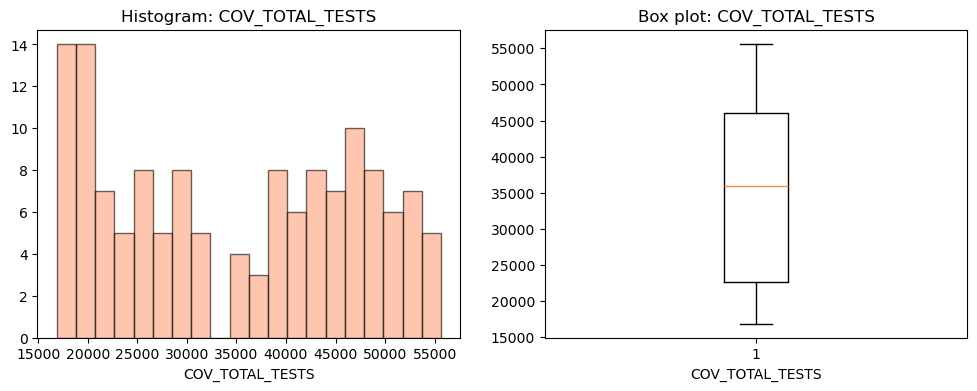

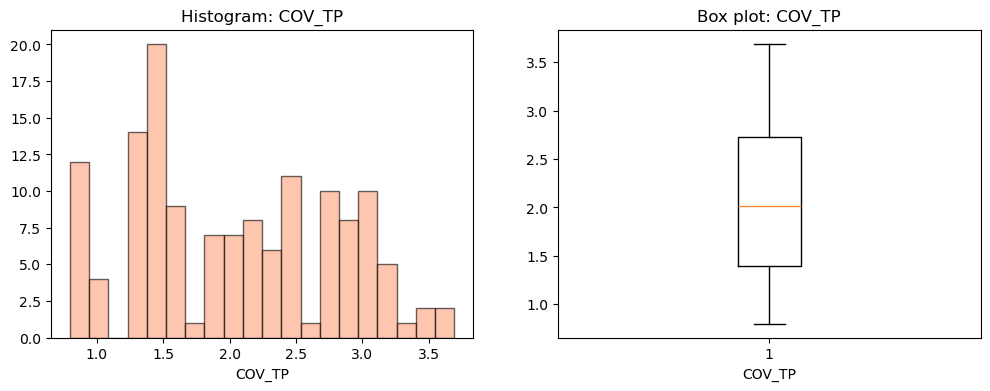

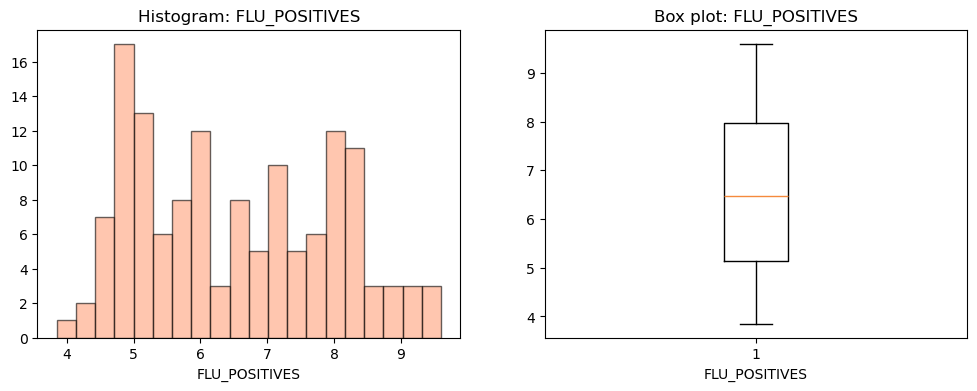

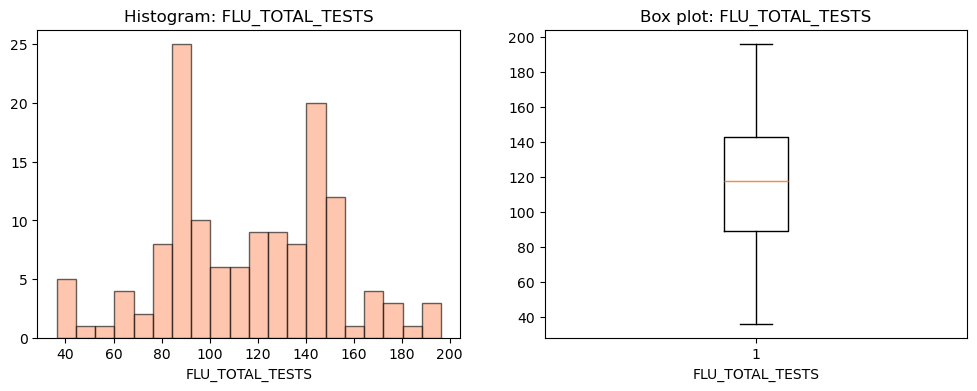

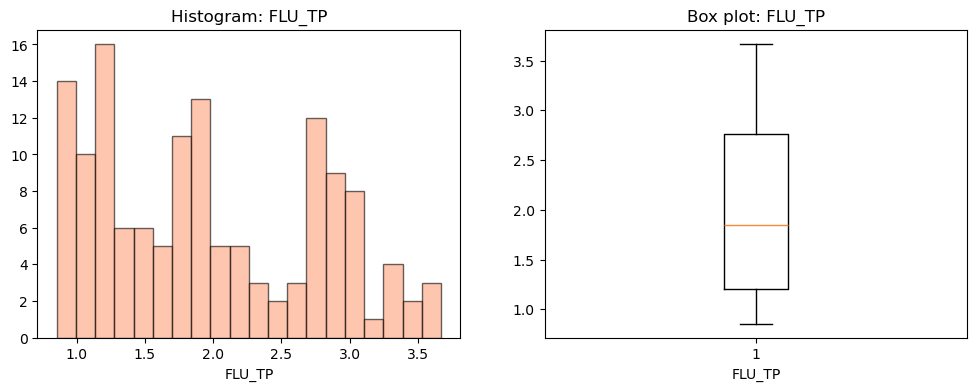

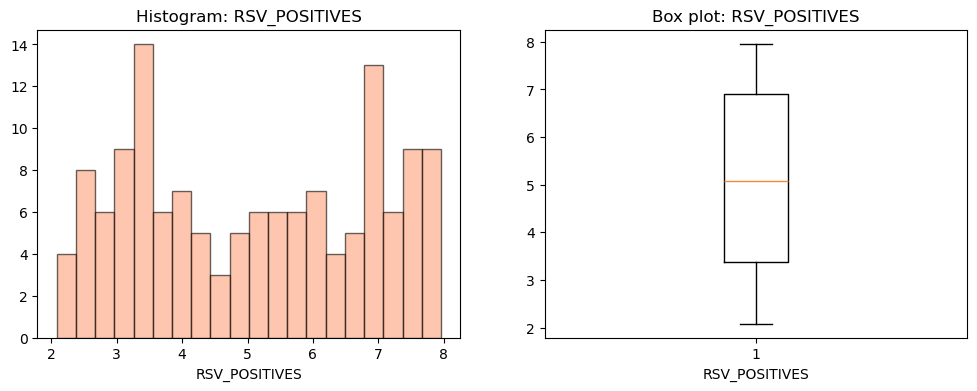

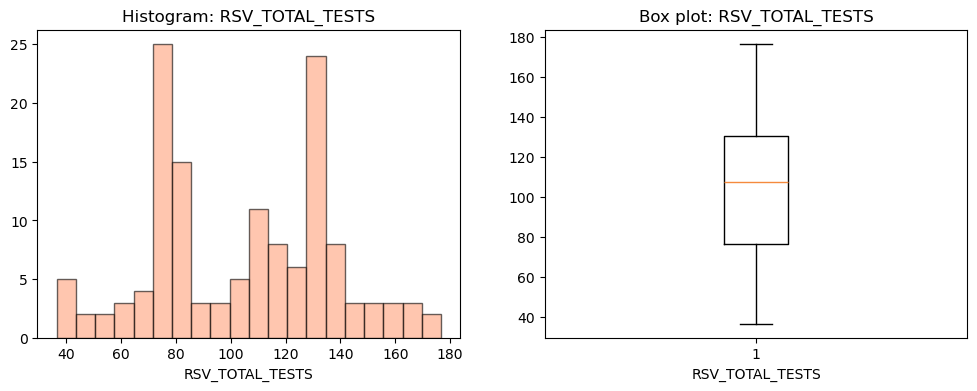

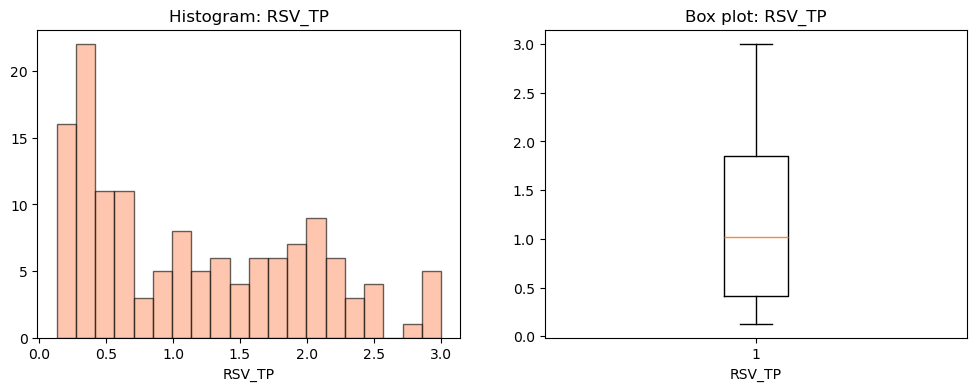

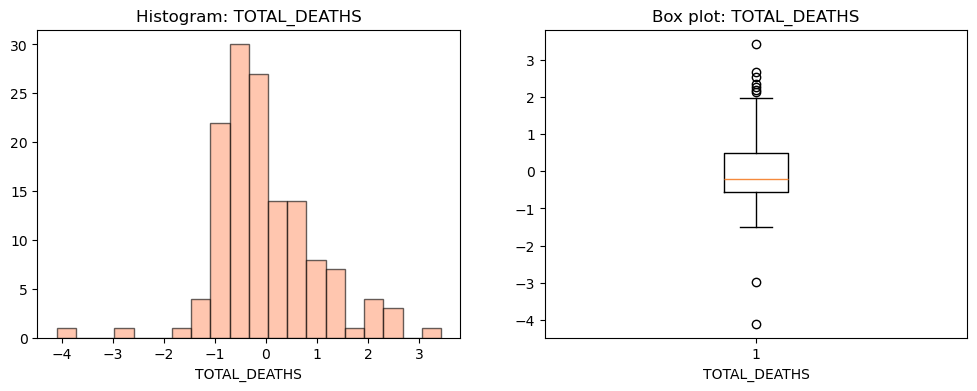

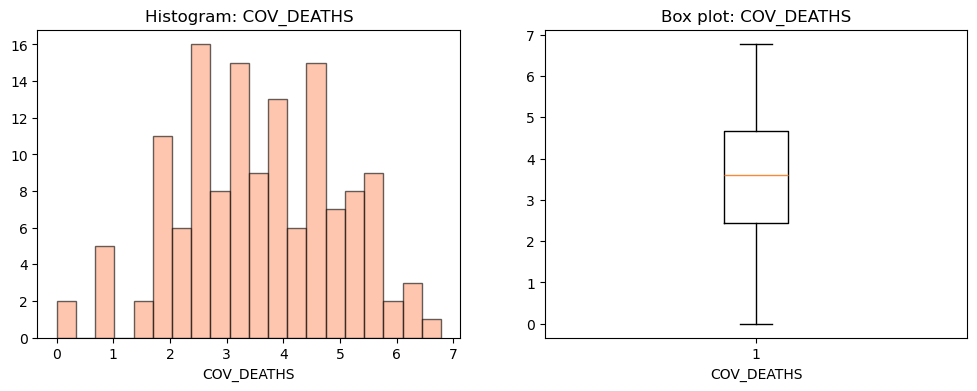

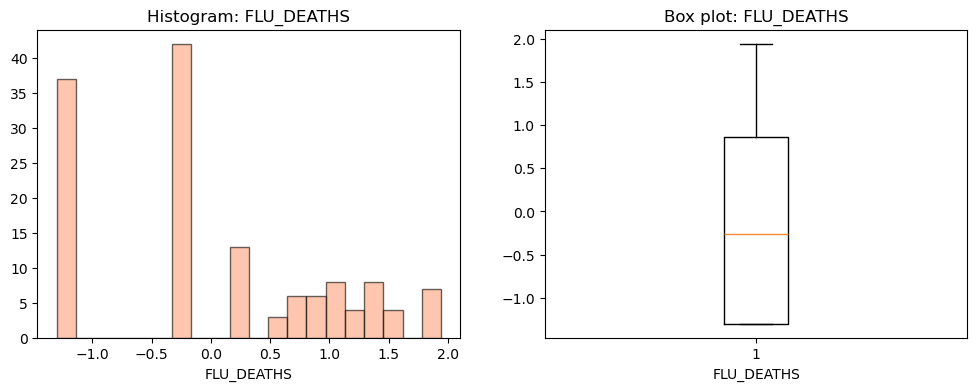

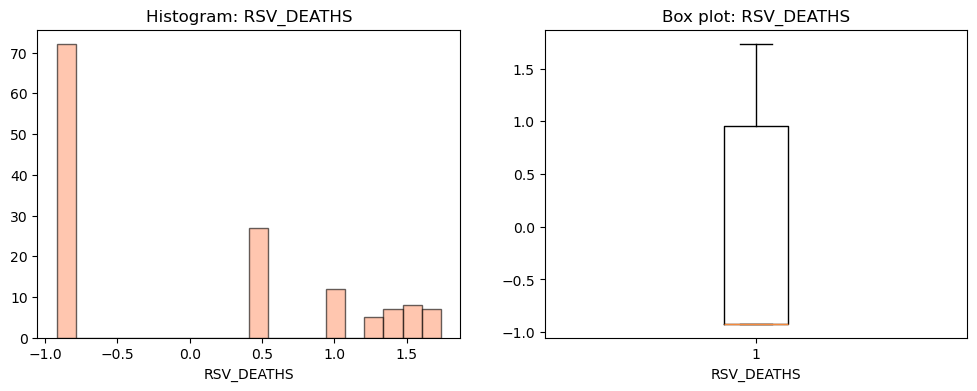

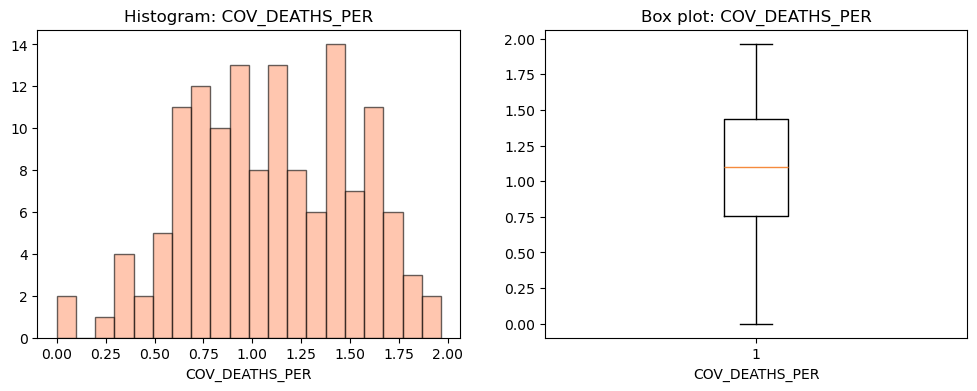

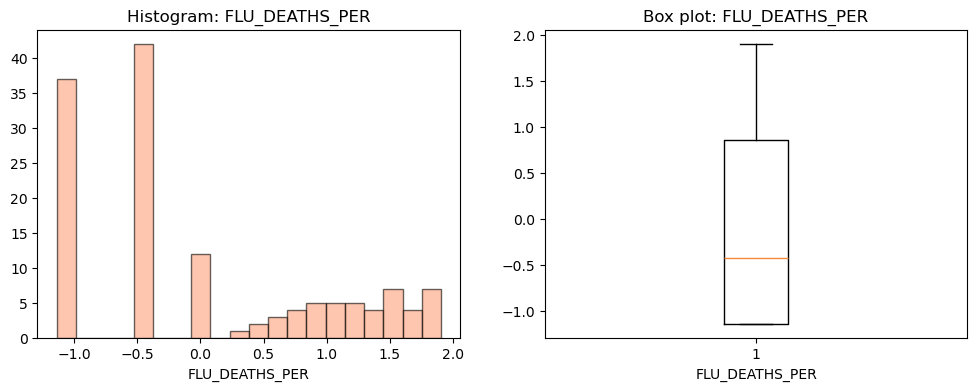

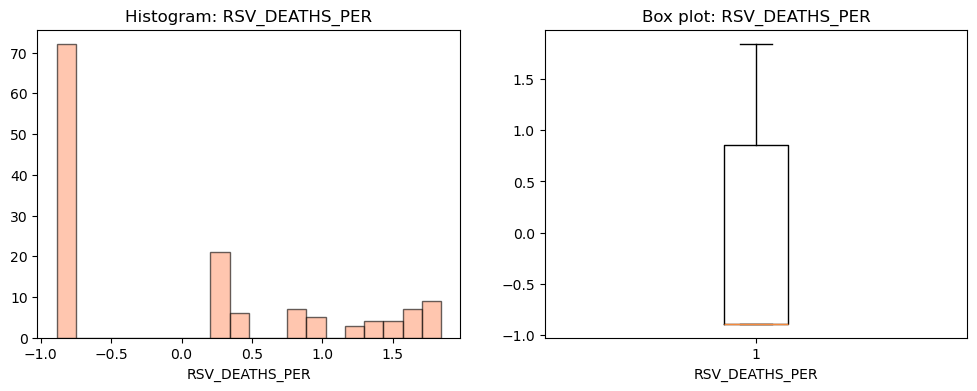

In [13]:
visualize_distribution(df_prep)

## Correlate  features

Identify which features move together. The top 5-8 features will be picked for use in data mining.

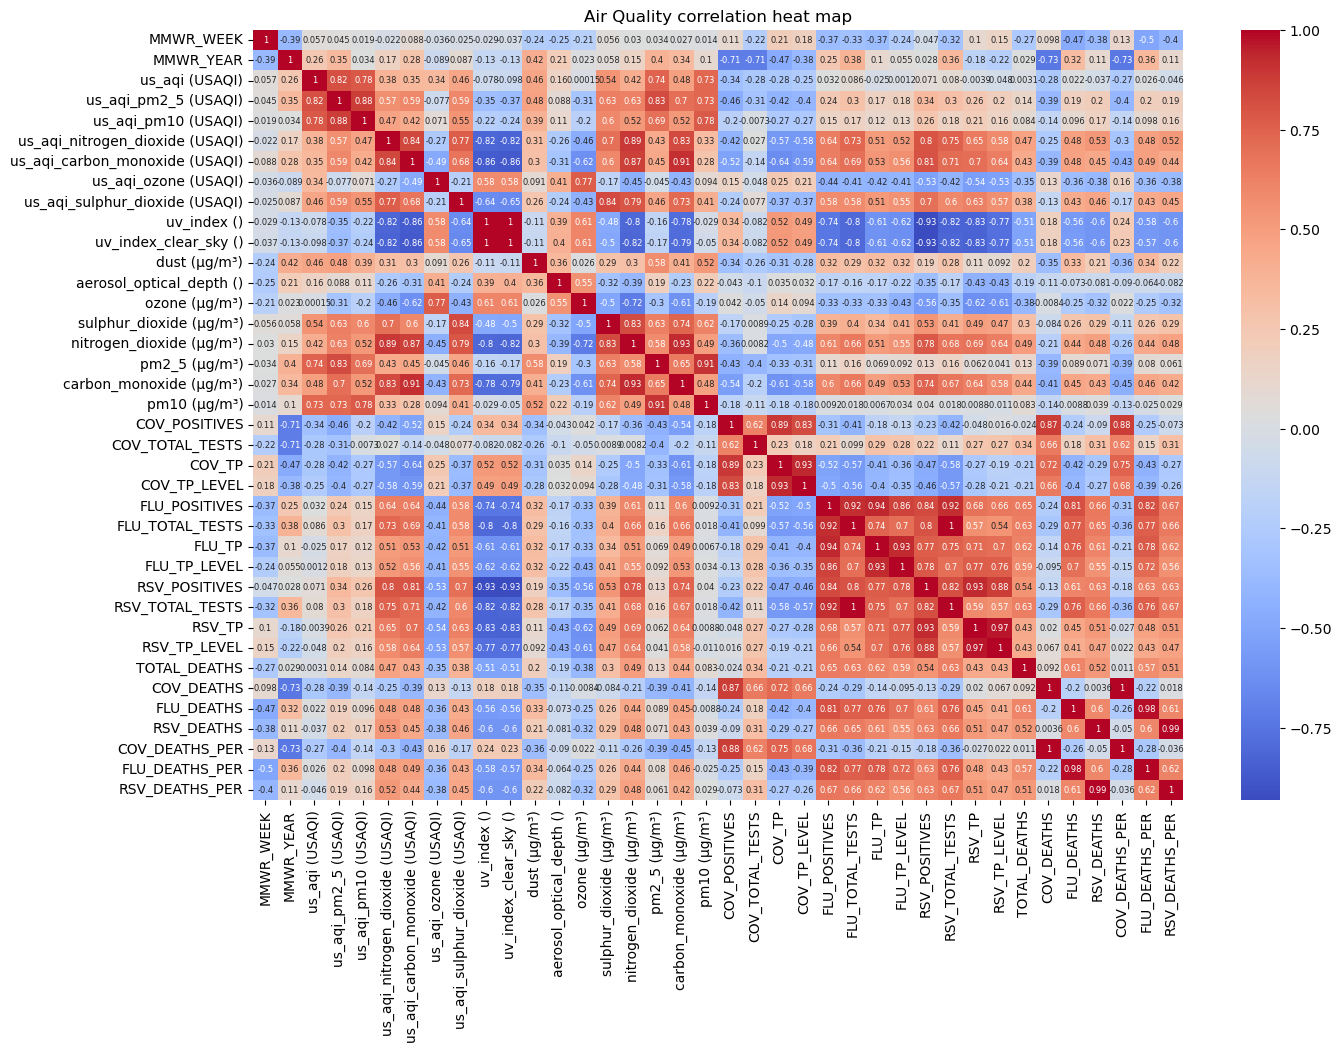

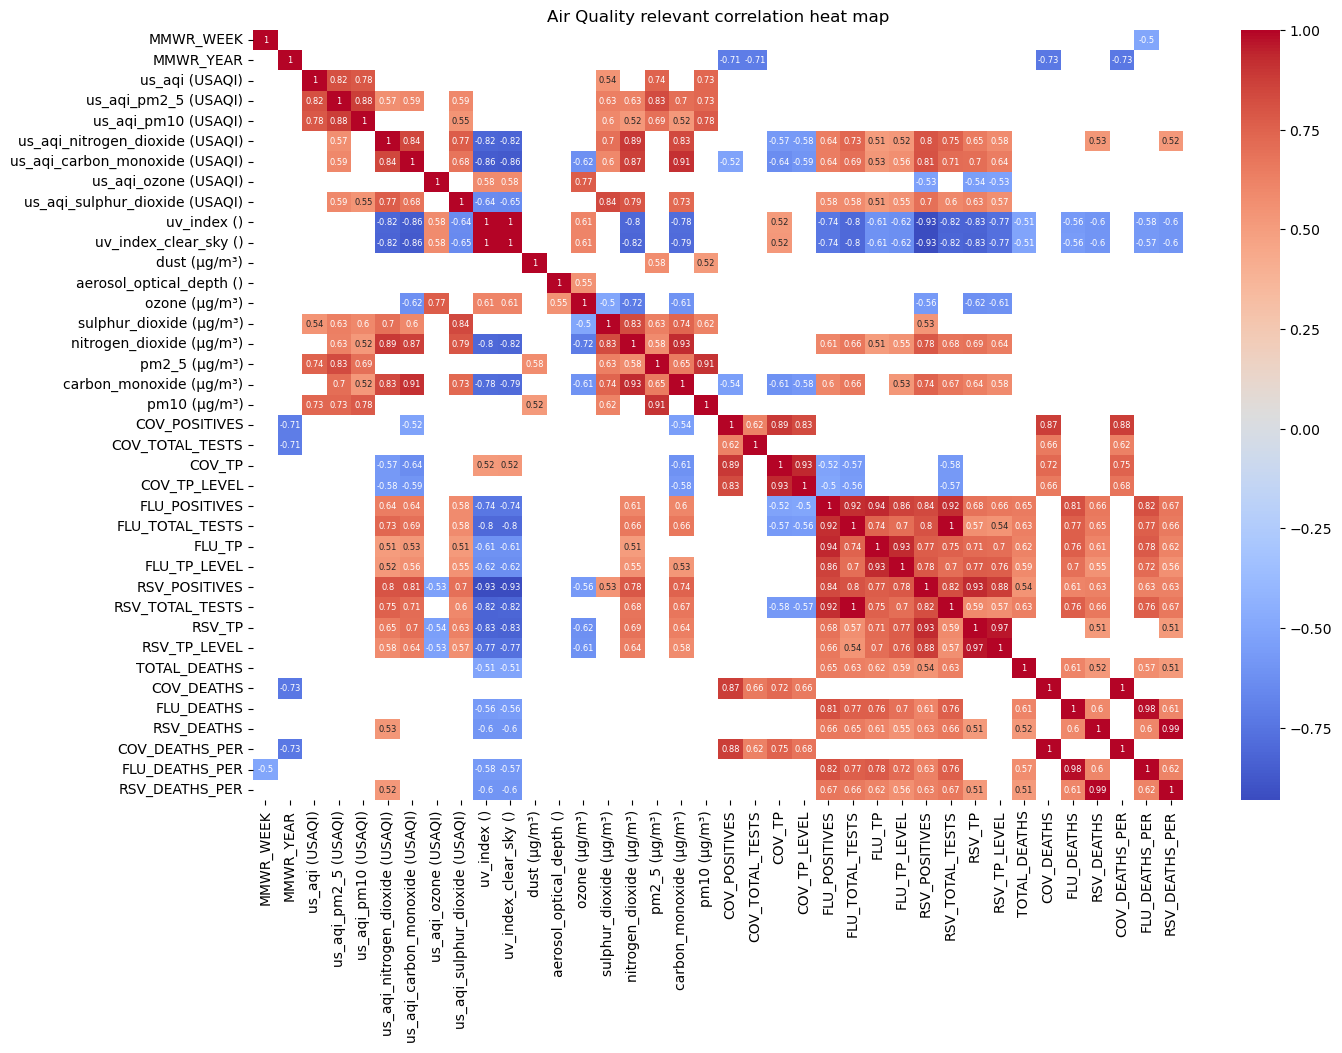

In [14]:
df_corr = df_prep.copy()
df_corr[prep_keys['COV_TP_LEVEL']] = df_corr[prep_keys['COV_TP_LEVEL']].cat.codes
df_corr[prep_keys['FLU_TP_LEVEL']] = df_corr[prep_keys['FLU_TP_LEVEL']].cat.codes
df_corr[prep_keys['RSV_TP_LEVEL']] = df_corr[prep_keys['RSV_TP_LEVEL']].cat.codes
correlate_features(df_corr, relevance=0.5, font_size=6)

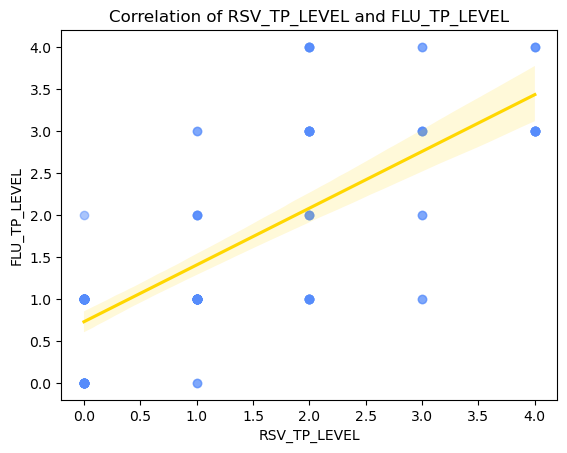

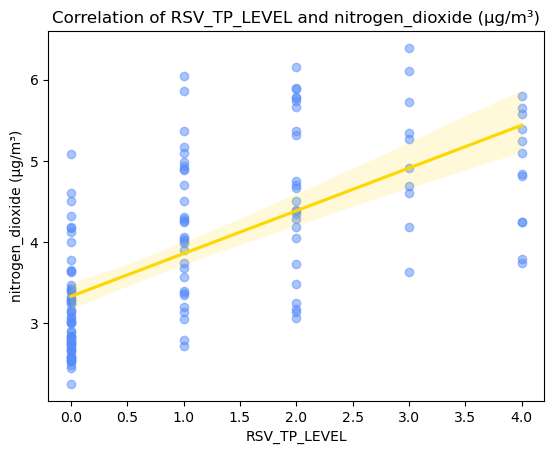

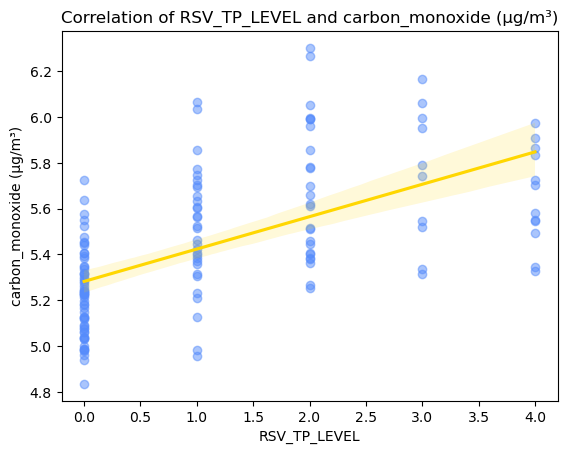

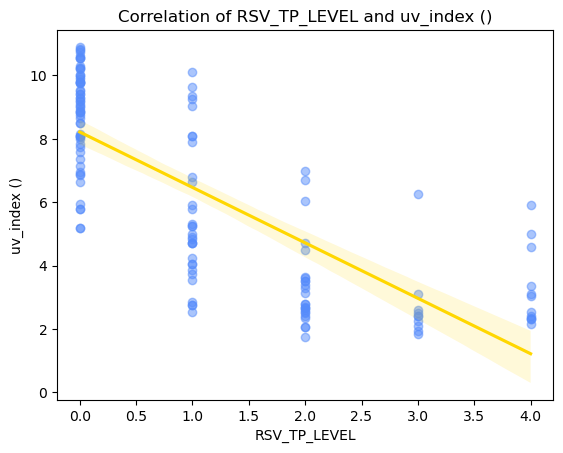

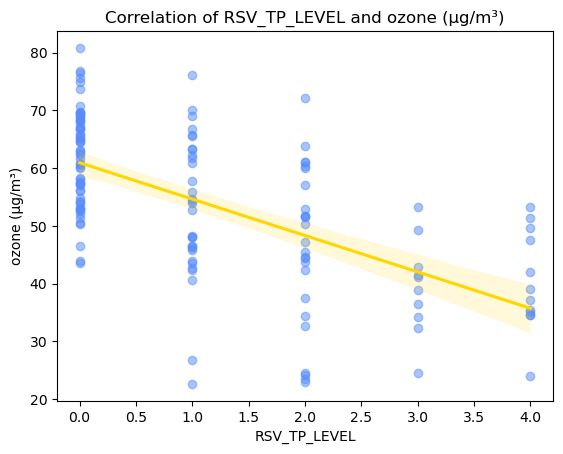

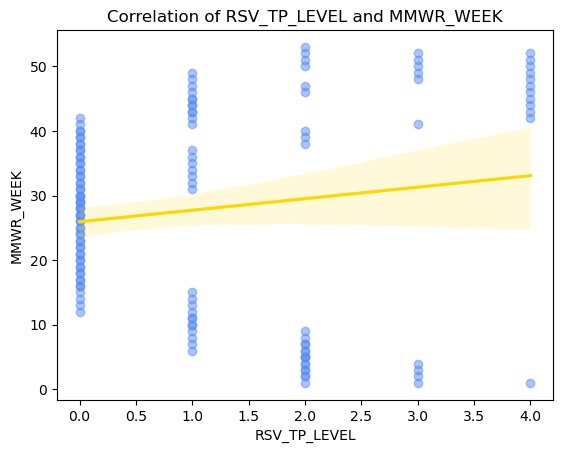

In [15]:
scatter_plot_features(df_corr, [
    [prep_keys['RSV_TP_LEVEL'], prep_keys['FLU_TP_LEVEL']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['nitrogen_dioxide (μg/m³)']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['carbon_monoxide (μg/m³)']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['uv_index ()']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['ozone (μg/m³)']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['MMWR_WEEK']],
])

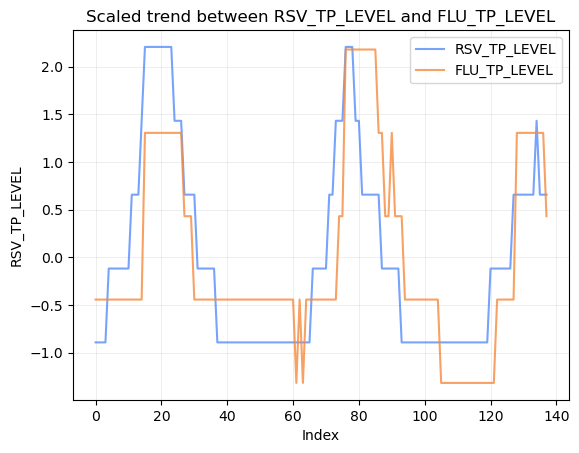

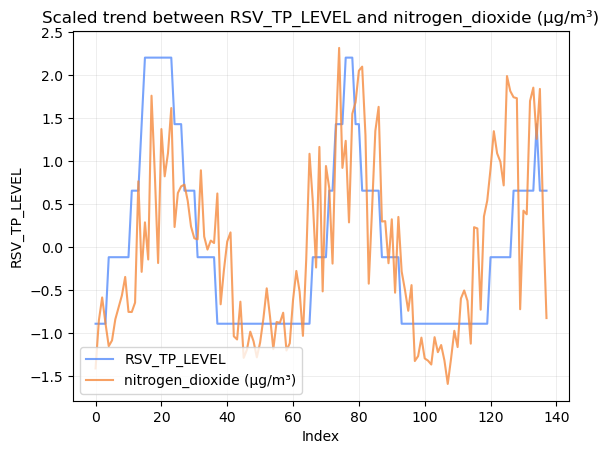

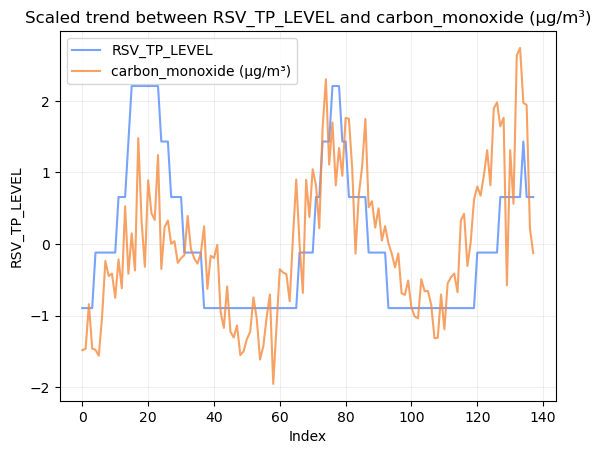

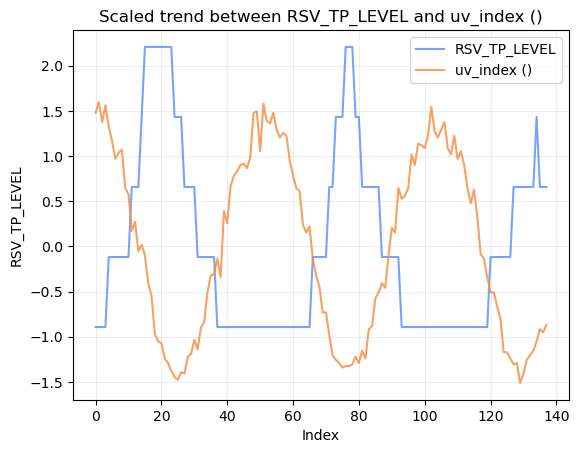

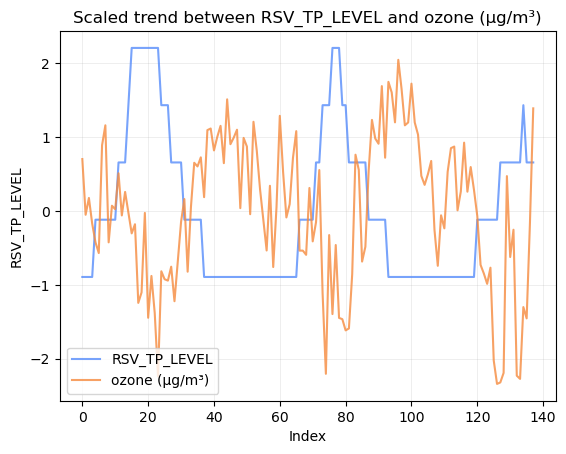

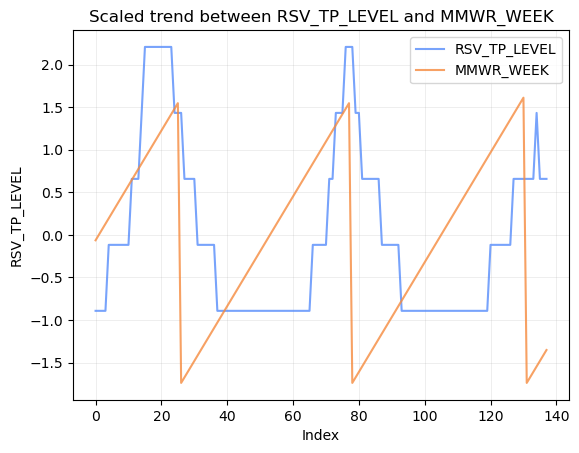

In [16]:
line_plot_features(df_corr, [
    [prep_keys['RSV_TP_LEVEL'], prep_keys['FLU_TP_LEVEL']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['nitrogen_dioxide (μg/m³)']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['carbon_monoxide (μg/m³)']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['uv_index ()']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['ozone (μg/m³)']],
    [prep_keys['RSV_TP_LEVEL'], prep_keys['MMWR_WEEK']],
])

## Pick features

Pick, aggregate, and stitch target and independent features from air quality and respiratory virus datasets for mining.

In [19]:
aq_pick = pd.read_csv(files['data/02-28-open-meteo-base.csv'])
rv_pick = pd.read_csv(files['data/02-28-respiratory-virus-dashboard-base.csv'])

# Pick respiratory virus dataset features
is_bay_area_region = rv_pick[rv_keys['RPHO_REGION']] == 'Bay Area'
is_all_ages_age_group = rv_pick[rv_keys['AGE_GRP']] == 'All Ages'
rv_pick = rv_pick[is_bay_area_region & is_all_ages_age_group]

rv_pick = rv_pick[[
    rv_keys['RSV_TP_LEVEL'],
    rv_keys['MMWR_WEEK'],
    rv_keys['MMWR_YEAR'],
    rv_keys['SEASON'],
    rv_keys['WEEKENDING'],
]]

# Pick air quality dataset features
aq_pick[[
    rv_keys['SEASON'],
    rv_keys['WEEKENDING'],
    rv_keys['MMWR_WEEK'],
    rv_keys['MMWR_YEAR']
]] = aq_pick[aq_keys['time']].apply(lambda x: pd.Series(derive_epi(x)))
aq_pick = aq_pick[[
    aq_keys['nitrogen_dioxide (μg/m³)'],
    aq_keys['carbon_monoxide (μg/m³)'],
    aq_keys['uv_index ()'],
    aq_keys['ozone (μg/m³)'],
    rv_keys['MMWR_WEEK'],
    rv_keys['MMWR_YEAR'],
    rv_keys['SEASON'],
    rv_keys['WEEKENDING']
]]
aq_pick = aq_pick.groupby([
    rv_keys['SEASON'],
    rv_keys['WEEKENDING'],
    rv_keys['MMWR_WEEK'],
    rv_keys['MMWR_YEAR']
]).agg({
    aq_keys['nitrogen_dioxide (μg/m³)']: 'mean',
    aq_keys['carbon_monoxide (μg/m³)']: 'mean',
    aq_keys['uv_index ()']: 'max',
    aq_keys['ozone (μg/m³)']: 'mean',
}).reset_index()

# Stitch datasets
df_pick = pd.merge(
    aq_pick,
    rv_pick,
    on=[
        rv_keys['SEASON'],
        rv_keys['WEEKENDING'],
        rv_keys['MMWR_WEEK'],
        rv_keys['MMWR_YEAR']
    ],
    how='inner'
)

df_pick = df_pick.sort_values(by=[rv_keys['MMWR_YEAR'], rv_keys['MMWR_WEEK']])
df_pick = df_pick[[
    keys['RSV_TP_LEVEL'],
    keys['nitrogen_dioxide (μg/m³)'],
    keys['carbon_monoxide (μg/m³)'],
    keys['uv_index ()'],
    keys['ozone (μg/m³)'],
    keys['MMWR_WEEK'],
]]
df_pick.to_csv(files['data/04-03-dataset.csv'], index=False)